# BARRA-RE2 wind drought day frequency from yearly masks

This notebook follows the same plotting template as the ERA5 wind drought day frequency notebook, but uses BARRA-RE2 yearly wind-drought mask files.

Main change:

- BARRA-RE2 has 22 realizations.
- For each year, drought days are first counted for each realization.
- Then the 22 realizations are averaged to produce one ensemble-mean annual drought-days field.
- Finally, 1990 to 2025 are averaged to produce one climatological annual drought-days map.

Input yearly mask dimensions expected:

`time, realization, lon, lat`

Output:

- One NetCDF file containing annual ensemble-mean drought days and climatological mean drought days.
- One PNG figure using the same ERA5 plotting template.


In [1]:
import os
from glob import glob
from pathlib import Path

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [2]:
# =====================
# Settings
# =====================
input_dir = "/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly"
output_dir = "/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis"
os.makedirs(output_dir, exist_ok=True)

start_year = 1990
end_year = 2025

lon_min, lon_max = 110, 160
lat_min, lat_max = -45, -10

threshold_percentile = 20
persistence_days = 3

files = sorted(glob(os.path.join(input_dir, "wind_drought_P20_3day_*.nc")))

# Keep only requested years
use_files = []
for fp in files:
    year = int(os.path.basename(fp).split("_")[-1].split(".")[0])
    if start_year <= year <= end_year:
        use_files.append(fp)

files = use_files

print(f"Files found: {len(files)}")
print("First file:", files[0])
print("Last file :", files[-1])
print("Output directory:", output_dir)


Files found: 36
First file: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_1990.nc
Last file : /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_2025.nc
Output directory: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis


In [3]:
# =====================
# Inspect one file
# =====================
with xr.open_dataset(files[0], engine="netcdf4", decode_times=True) as ds0:
    print(ds0)
    print("Data variables:", list(ds0.data_vars))

    if "wind_drought" in ds0.data_vars:
        drought_var = "wind_drought"
    else:
        drought_var = list(ds0.data_vars)[0]

    print("Using variable:", drought_var)
    print("Variable dims:", ds0[drought_var].dims)
    print("Variable shape:", ds0[drought_var].shape)


<xarray.Dataset> Size: 1GB
Dimensions:       (time: 365, realization: 22, lon: 227, lat: 159)
Coordinates:
  * time          (time) datetime64[ns] 3kB 1990-01-01T12:00:00 ... 1990-12-3...
  * realization   (realization) <U5 440B '000_0' '000_1' ... 'ctl_0' 'ctl_1'
  * lon           (lon) float64 2kB 110.2 110.4 110.7 ... 159.5 159.7 159.9
  * lat           (lat) float64 1kB -44.83 -44.61 -44.39 ... -10.29 -10.07
Data variables:
    wind_drought  (time, realization, lon, lat) float32 1GB ...
Attributes:
    title:    BARRA-RE2 wind drought mask for 1990
    history:  Created from monthly wind100 files using fixed 1991-2020 P20 th...
    region:   Australia
    lon_min:  110
    lon_max:  160
    lat_min:  -45
    lat_max:  -10
Data variables: ['wind_drought']
Using variable: wind_drought
Variable dims: ('time', 'realization', 'lon', 'lat')
Variable shape: (365, 22, 227, 159)


In [4]:
# =====================
# Annual drought days
# =====================
annual_days_list = []
year_list = []

for fp in files:
    year = int(os.path.basename(fp).split("_")[-1].split(".")[0])
    print(f"Processing {year} ...", flush=True)

    ds = xr.open_dataset(fp, engine="netcdf4", decode_times=True)
    wd = ds[drought_var]

    # Crop Australia region
    wd = wd.where(
        (wd["lon"] >= lon_min) & (wd["lon"] <= lon_max) &
        (wd["lat"] >= lat_min) & (wd["lat"] <= lat_max),
        drop=True
    )

    # Number of drought days in that year for each realization
    days_by_realization = wd.sum(dim="time", skipna=True).astype("float32")

    # BARRA-RE2 has 22 realizations, take ensemble mean to get one output field per year
    days_year = days_by_realization.mean(dim="realization", skipna=True).astype("float32")

    days_year.name = "wind_drought_days"
    days_year.attrs["long_name"] = "Annual wind drought days, ensemble mean across BARRA-RE2 realizations"
    days_year.attrs["units"] = "days/year"
    days_year.attrs["realization_handling"] = "sum over time for each realization, then mean across realizations"

    annual_days_list.append(days_year.load())
    year_list.append(year)

    ds.close()

annual_days = xr.concat(annual_days_list, dim="year")
annual_days = annual_days.assign_coords(year=year_list)
annual_days.name = "annual_wind_drought_days_ensemble_mean"
annual_days.attrs["long_name"] = "Annual wind drought days, ensemble mean across BARRA-RE2 realizations"
annual_days.attrs["units"] = "days/year"
annual_days.attrs["realization_handling"] = "22 BARRA-RE2 realizations averaged"

# Climatological mean annual drought days
clim_days = annual_days.mean(dim="year", skipna=True).astype("float32")
clim_days.name = "climatological_wind_drought_days"
clim_days.attrs["long_name"] = "Climatological mean wind drought days per year, BARRA-RE2 ensemble mean, 1990-2025"
clim_days.attrs["units"] = "days/year"
clim_days.attrs["realization_handling"] = "annual values are ensemble means across 22 BARRA-RE2 realizations"

print(annual_days)
print(clim_days)
print("Climatological min:", float(clim_days.min().values))
print("Climatological max:", float(clim_days.max().values))


Processing 1990 ...
Processing 1991 ...
Processing 1992 ...
Processing 1993 ...
Processing 1994 ...
Processing 1995 ...
Processing 1996 ...
Processing 1997 ...
Processing 1998 ...
Processing 1999 ...
Processing 2000 ...
Processing 2001 ...
Processing 2002 ...
Processing 2003 ...
Processing 2004 ...
Processing 2005 ...
Processing 2006 ...
Processing 2007 ...
Processing 2008 ...
Processing 2009 ...
Processing 2010 ...
Processing 2011 ...
Processing 2012 ...
Processing 2013 ...
Processing 2014 ...
Processing 2015 ...
Processing 2016 ...
Processing 2017 ...
Processing 2018 ...
Processing 2019 ...
Processing 2020 ...
Processing 2021 ...
Processing 2022 ...
Processing 2023 ...
Processing 2024 ...
Processing 2025 ...
<xarray.DataArray 'annual_wind_drought_days_ensemble_mean' (year: 36, lon: 227,
                                                            lat: 159)> Size: 5MB
array([[[25.90909  , 27.       , 27.09091  , ..., 57.409092 ,
         57.18182  , 57.81818  ],
        [26.136364 , 27

In [6]:
# =====================
# Save one NetCDF output
# =====================
out_nc = os.path.join(
    output_dir,
    "BARRA_RE2_P20_3day_annual_wind_drought_days_ensemble_mean_1990_2025.nc"
)

out_ds = xr.Dataset(
    {
        "annual_wind_drought_days_ensemble_mean": annual_days,
        "climatological_wind_drought_days": clim_days,
    }
)

out_ds.attrs["title"] = "BARRA-RE2 wind drought day frequency"
out_ds.attrs["description"] = (
    "Annual wind drought days from yearly P20 3-day wind drought masks. "
    "Each year is first summed over time for each realization, then averaged "
    "across 22 BARRA-RE2 realizations. The climatological field is the mean "
    "annual drought days from 1990 to 2025."
)
out_ds.attrs["threshold"] = f"P{threshold_percentile}"
out_ds.attrs["duration"] = f">= {persistence_days} consecutive days"
out_ds.attrs["period"] = f"{start_year}-{end_year}"
out_ds.attrs["input_dir"] = input_dir

encoding = {
    "annual_wind_drought_days_ensemble_mean": {
        "zlib": True,
        "complevel": 4,
        "shuffle": True,
        "dtype": "float32",
    },
    "climatological_wind_drought_days": {
        "zlib": True,
        "complevel": 4,
        "shuffle": True,
        "dtype": "float32",
    },
}

out_ds.to_netcdf(out_nc, engine="netcdf4", encoding=encoding)

print("Saved:", out_nc)


Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/BARRA_RE2_P20_3day_annual_wind_drought_days_ensemble_mean_1990_2025.nc


Plot dims : ('latitude', 'longitude')
Plot shape: (159, 227)
Longitude length: 227
Latitude length : 159


/g/data/x77/ha2606/envs/weasel-gpu/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/g/data/x77/ha2606/envs/weasel-gpu/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces_lines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


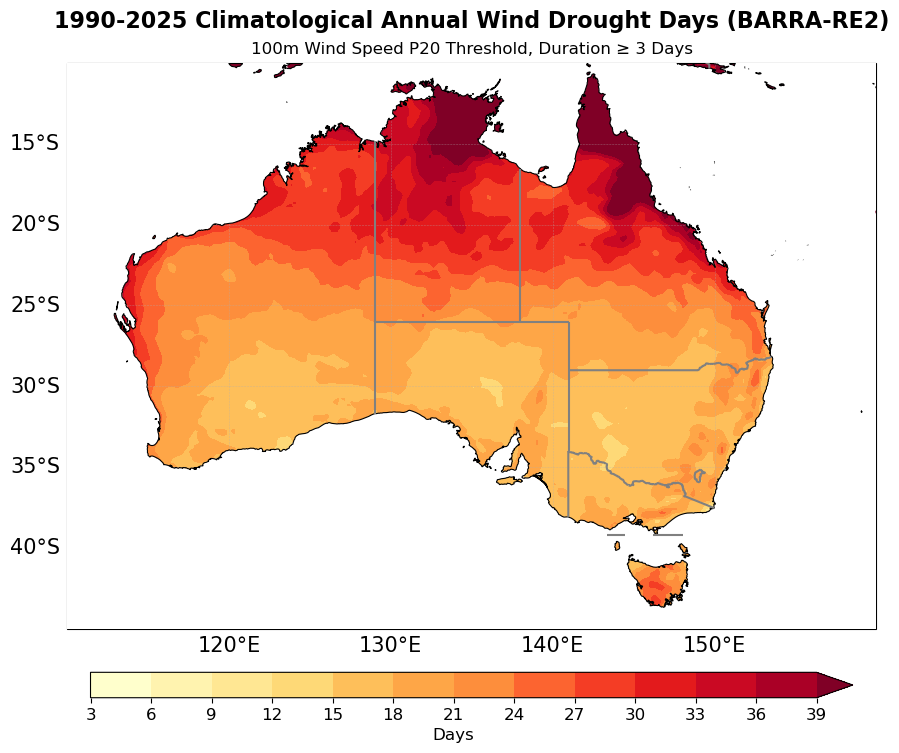

Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/BARRA_RE2_P20_3day_climatological_drought_days_ensemble_mean.png


In [9]:
# =====================
# Plot variable
# =====================
days_plot = clim_days

# Rename only for matching the ERA5 plotting template
if "lon" in days_plot.dims:
    days_plot = days_plot.rename({"lon": "longitude"})
if "lat" in days_plot.dims:
    days_plot = days_plot.rename({"lat": "latitude"})

# IMPORTANT FIX:
# BARRA-RE2 is stored as longitude, latitude.
# contourf needs latitude, longitude.
days_plot = days_plot.transpose("latitude", "longitude")

print("Plot dims :", days_plot.dims)
print("Plot shape:", days_plot.shape)
print("Longitude length:", days_plot.sizes["longitude"])
print("Latitude length :", days_plot.sizes["latitude"])

# =====================
# Colormap
# =====================
cmap = plt.cm.YlOrRd.copy()
cmap.set_under("white")

levels = np.arange(3, 42, 3)

norm = mcolors.BoundaryNorm(
    levels,
    cmap.N,
    extend="max"
)

# =====================
# Figure
# =====================
fig = plt.figure(figsize=(10, 8))

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

# =====================
# Filled contours
# =====================
cf = ax.contourf(
    days_plot["longitude"],
    days_plot["latitude"],
    days_plot,
    levels=levels,
    cmap=cmap,
    norm=norm,
    extend="max",
    transform=ccrs.PlateCarree()
)

# =====================
# Ocean mask
# =====================
ax.add_feature(
    cfeature.OCEAN,
    facecolor="white",
    edgecolor="none",
    zorder=100
)

# =====================
# Coastline
# =====================
ax.coastlines(
    resolution="10m",
    linewidth=0.8,
    color="black",
    zorder=101
)

# =====================
# Australian state boundaries
# =====================
states = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_1_states_provinces_lines",
    scale="10m",
    facecolor="none"
)

ax.add_feature(
    states,
    edgecolor="grey",
    linewidth=1.5,
    zorder=102
)

# =====================
# Domain
# =====================
ax.set_extent(
    [110, 160, -45, -10],
    crs=ccrs.PlateCarree()
)

# =====================
# Gridlines
# =====================
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    linestyle="--",
    alpha=0.5
)

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {"size": 15}
gl.ylabel_style = {"size": 15}

# =====================
# Colorbar
# =====================
cbar = plt.colorbar(
    cf,
    orientation="horizontal",
    pad=0.06,
    shrink=0.8,
    aspect=30
)

cbar.set_label(
    "Days",
    fontsize=12
)

cbar.set_ticks(
    np.arange(3, 42, 3)
)

cbar.ax.tick_params(
    labelsize=12
)

# =====================
# Title
# =====================
ax.set_title(
    "1990-2025 Climatological Annual Wind Drought Days (BARRA-RE2)",
    fontsize=16,
    fontweight="bold",
    pad=25
)

ax.text(
    0.5,
    1.01,
    "100m Wind Speed P20 Threshold, Duration ≥ 3 Days",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=12,
    fontweight="normal"
)

# =====================
# Save
# =====================
plt.tight_layout()

out_png = os.path.join(
    output_dir,
    "BARRA_RE2_P20_3day_climatological_drought_days_ensemble_mean.png"
)

plt.savefig(
    out_png,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", out_png)

In [10]:
# =====================
# Quick check saved NetCDF
# =====================
check = xr.open_dataset(out_nc, engine="netcdf4")
print(check)
print("Annual variable:", check["annual_wind_drought_days_ensemble_mean"])
print("Climatological variable:", check["climatological_wind_drought_days"])
check.close()


<xarray.Dataset> Size: 5MB
Dimensions:                                 (year: 36, lon: 227, lat: 159)
Coordinates:
  * lon                                     (lon) float64 2kB 110.2 ... 159.9
  * lat                                     (lat) float64 1kB -44.83 ... -10.07
  * year                                    (year) int64 288B 1990 1991 ... 2025
Data variables:
    annual_wind_drought_days_ensemble_mean  (year, lon, lat) float32 5MB ...
    climatological_wind_drought_days        (lon, lat) float32 144kB ...
Attributes:
    title:        BARRA-RE2 wind drought day frequency
    description:  Annual wind drought days from yearly P20 3-day wind drought...
    threshold:    P20
    duration:     >= 3 consecutive days
    period:       1990-2025
    input_dir:    /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly
Annual variable: <xarray.DataArray 'annual_wind_drought_days_ensemble_mean' (year: 36, lon: 227,
                                                            lat: 159